In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np

import matplotlib.pyplot as plt

import yaml
from pathlib import Path

from thesis_project.datasets import SpeechCommandsGoogle
from thesis_project.datasets.speech_commands.config import ALL_KEYWORDS, CANONICAL, COMMAND_KEYWORDS_20, COMMAND_KEYWORDS_24
from thesis_project.utils.paths import get_data_dir

from thesis_project.models.architectures.keyword_spotting import KeyWordSpottingModel, KeyWordSpottingConfig, SpectrogramConfig, BackboneConfig, NoiseConfig



In [40]:
data_dir = get_data_dir()

In [41]:
# 1) Basic "canonical-style" setup: keywords + unknown + silence, no upsampling
ds = SpeechCommandsGoogle(
    root = data_dir,
    subset="training",
    keyword_list=CANONICAL,   # or a custom list
    use_unknown=False,
    use_silence=True,
    upsample=False,
    snr=20,                 # or e.g. (0.0, 10.0)
    noise_prob=1.0,         # probability of adding noise
)
print("Number of samples:", len(ds))
print("Labels:", ds.labels)
print("Label to idx:", ds.label_to_idx)
print("Label counts:", ds.label_counts)


Number of samples: 33997
Labels: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', 'SILENCE']
Label to idx: {'down': 0, 'go': 1, 'left': 2, 'no': 3, 'off': 4, 'on': 5, 'right': 6, 'stop': 7, 'up': 8, 'yes': 9, 'SILENCE': 10}
Label counts: Counter({'yes': 3228, 'SILENCE': 3228, 'down': 3134, 'no': 3130, 'stop': 3111, 'go': 3106, 'on': 3086, 'left': 3037, 'right': 3019, 'off': 2970, 'up': 2948})


In [42]:
# 2) Fetch a few samples
for i in range(20):
    waveform, label_idx, meta = ds[i]
    print(f"\nSample {i}:")
    print("  waveform shape:", tuple(waveform.shape))
    print("  label_idx:", label_idx, "->", ds.idx_to_label[label_idx])
    print("  meta['label']:", meta["label"])
    print("  meta['utterance']:", meta["utterance"])
    print("  meta['speaker_id']:", meta["speaker_id"])
    print("  meta['utterance_number']:", meta["utterance_number"])
    print("  meta['sample_rate']:", meta["sample_rate"])
    print("  meta['snr]:", meta.get("snr", None))


Sample 0:
  waveform shape: (1, 16000)
  label_idx: 0 -> down
  meta['label']: down
  meta['utterance']: down
  meta['speaker_id']: 00176480
  meta['utterance_number']: 0
  meta['sample_rate']: 16000
  meta['snr]: 20.0

Sample 1:
  waveform shape: (1, 16000)
  label_idx: 0 -> down
  meta['label']: down
  meta['utterance']: down
  meta['speaker_id']: 004ae714
  meta['utterance_number']: 0
  meta['sample_rate']: 16000
  meta['snr]: 20.0

Sample 2:
  waveform shape: (1, 16000)
  label_idx: 0 -> down
  meta['label']: down
  meta['utterance']: down
  meta['speaker_id']: 00b01445
  meta['utterance_number']: 0
  meta['sample_rate']: 16000
  meta['snr]: 20.0

Sample 3:
  waveform shape: (1, 16000)
  label_idx: 0 -> down
  meta['label']: down
  meta['utterance']: down
  meta['speaker_id']: 00b01445
  meta['utterance_number']: 1
  meta['sample_rate']: 16000
  meta['snr]: 20.0

Sample 4:
  waveform shape: (1, 16000)
  label_idx: 0 -> down
  meta['label']: down
  meta['utterance']: down
  meta['s

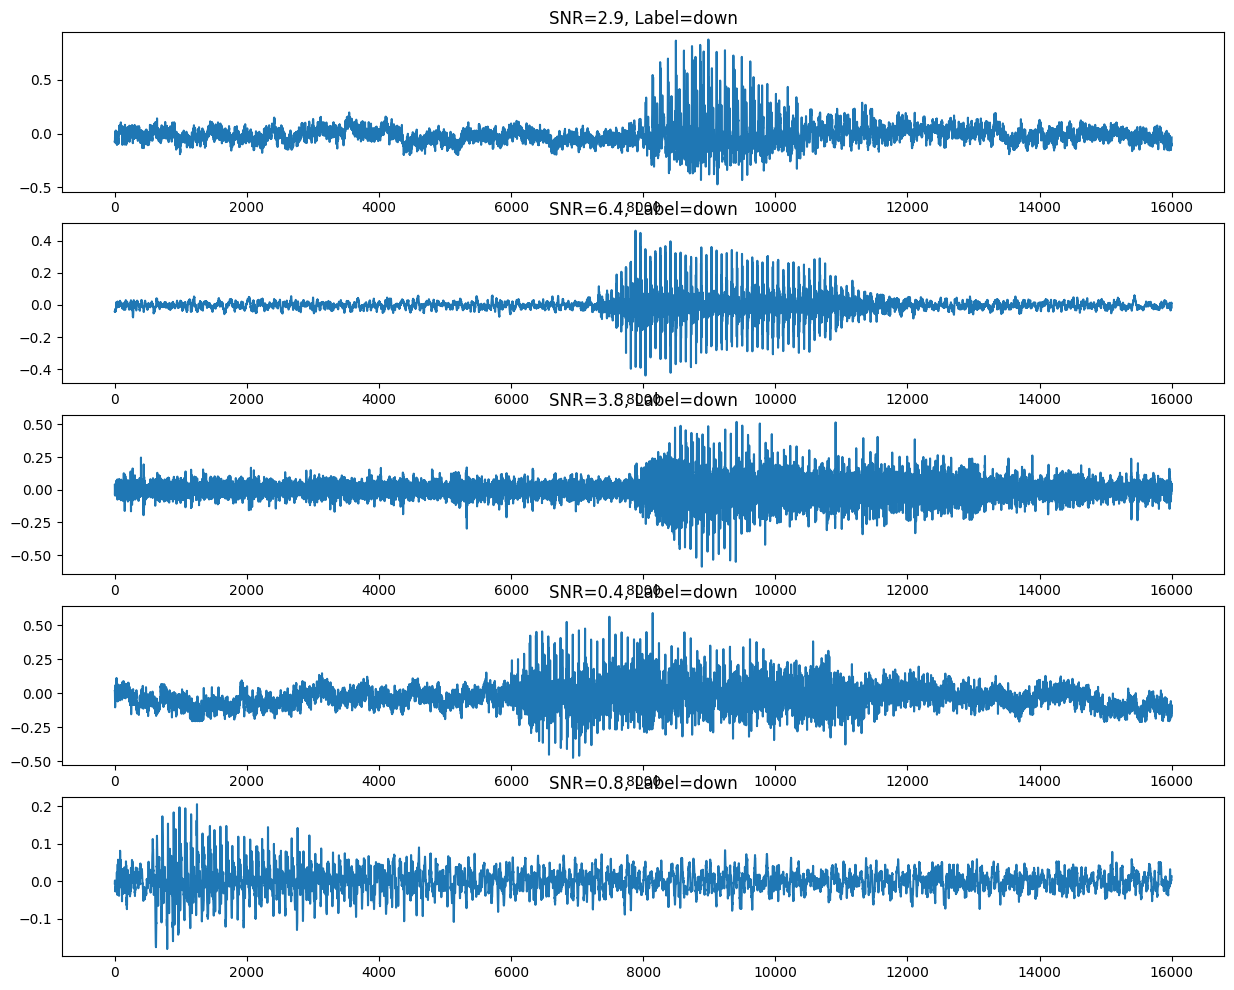

In [43]:
#3) Fetch a few samples but snr is a range (tuple) and visualize
plt.figure(figsize=(15, 12))
ds._set_snr((0.0,10.0))
for i in range(5):
    waveform, label_idx, meta = ds[i]
    plt.subplot(5,1,i+1)
    plt.plot(waveform.t().numpy())
    plt.title(f"SNR={meta.get('snr', None):.1f}, Label={meta['label']}")



🎧 SNR=-10 — audio:



🎧 SNR=-5 — audio:



🎧 SNR=0 — audio:



🎧 SNR=5 — audio:



🎧 SNR=10 — audio:



🎧 SNR=15 — audio:


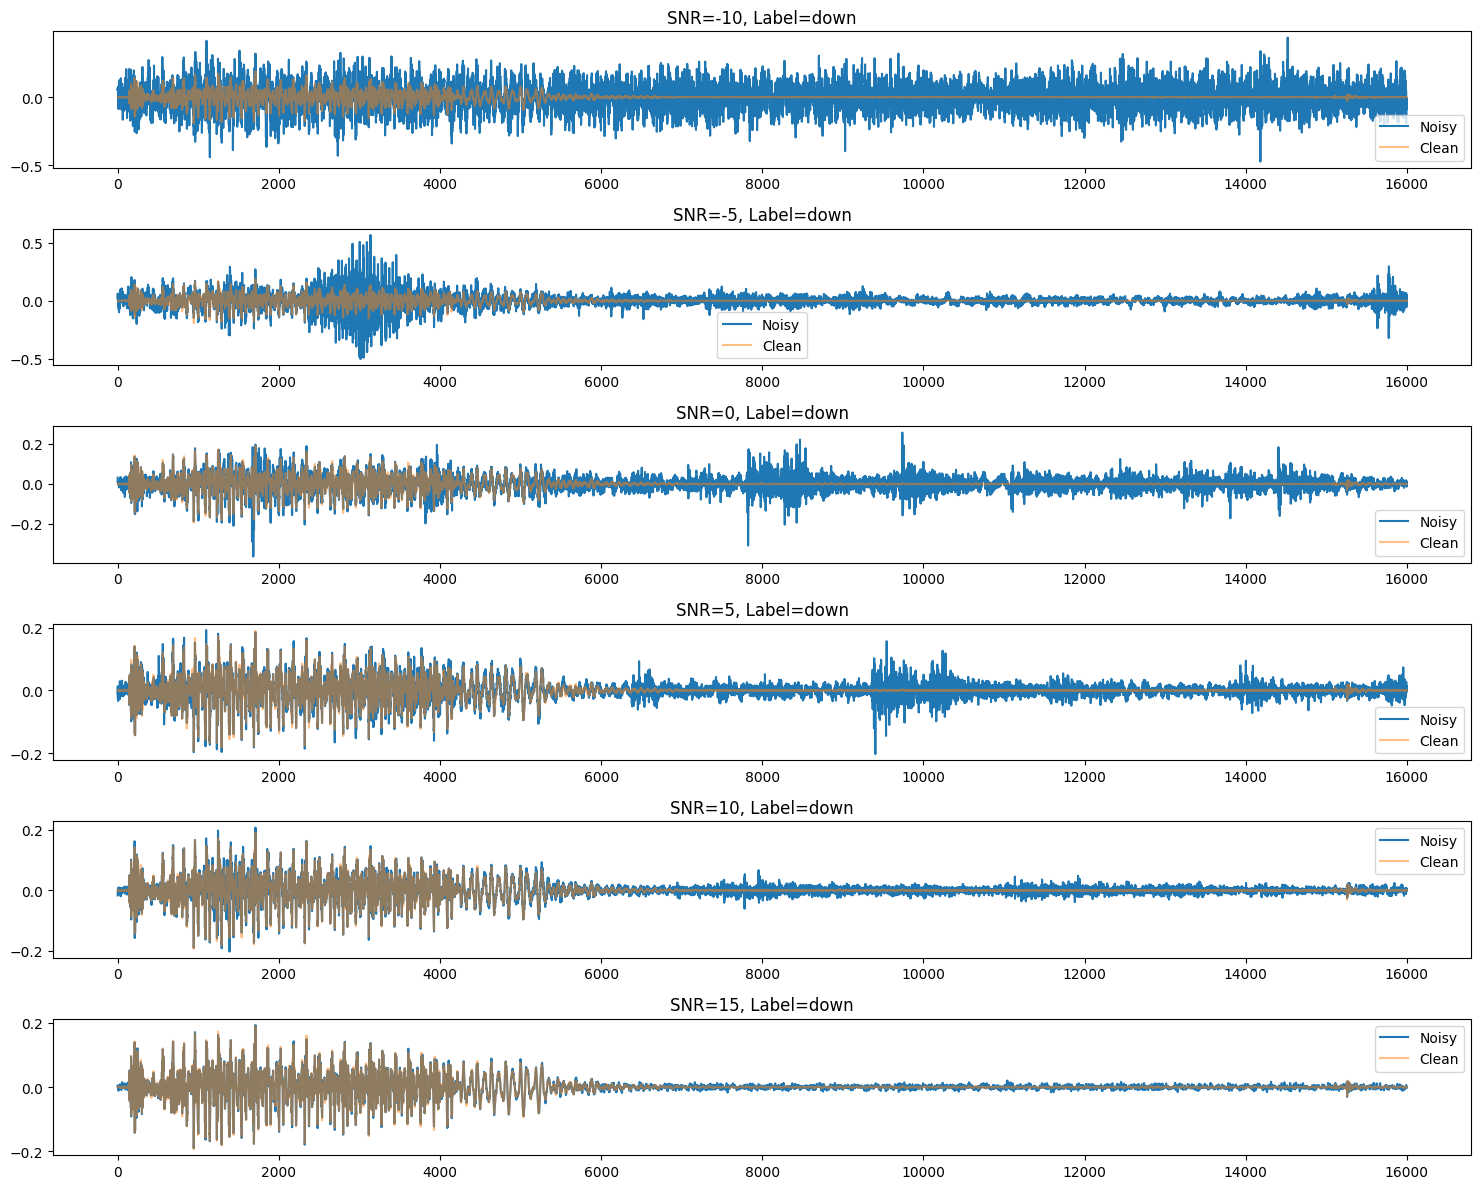

In [44]:
# 4) Visualize and listen to sample waveform with different SNR values
from IPython.display import Audio, display
import matplotlib.pyplot as plt

snrs = [-10, -5, 0, 5, 10, 15]

plt.figure(figsize=(15, 12))

for i, snr in enumerate(snrs):
    ds._set_snr(snr)
    noisy_waveform, label_idx, meta = ds[32]
    clean_waveform = meta["waveform_post_transform"]
    sr = meta["sample_rate"]

    # ----- Plot -----
    plt.subplot(len(snrs), 1, i + 1)
    plt.plot(noisy_waveform.t().numpy(), label="Noisy")
    plt.plot(clean_waveform.t().numpy(), alpha=0.5, label="Clean")
    plt.title(f"SNR={snr}, Label={meta['label']}")
    plt.legend()
    plt.tight_layout()

    # ----- Audio playback -----
    print(f"\n🎧 SNR={snr} — audio:")
    display(Audio(noisy_waveform.squeeze().numpy(), rate=sr))

plt.show()


In [45]:
meta

{'sample_rate': 16000,
 'label': 'down',
 'utterance': 'down',
 'utterance_number': 0,
 'speaker_id': '02746d24',
 'waveform_post_transform': tensor([[0.0005, 0.0013, 0.0002,  ..., 0.0011, 0.0004, 0.0006]]),
 'noise': tensor([[ 0.0110,  0.0179,  0.0129,  ..., -0.0195, -0.0105, -0.0007]]),
 'noise_type': 'doing_the_dishes',
 'snr': 15.0}

In [46]:
#5) fetch a batch through a DataLoader
train_set = SpeechCommandsGoogle(
    root = data_dir,
    subset="training",
    keyword_list=CANONICAL,   # or a custom list
    use_unknown=True,
    use_silence=True,
    upsample=False,
    snr=(-5,15),                 # or e.g. (0.0, 10.0)
)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
batch = next(iter(train_loader))


In [47]:
#6) same but no snr
train_set = SpeechCommandsGoogle(
    root = data_dir,
    subset="training",
    keyword_list=CANONICAL,   # or a custom list
    use_unknown=True,
    use_silence=True,
    upsample=False,
    snr=None,
)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
batch = next(iter(train_loader))

TypeError: snr must be a float or (float, float).

In [ ]:
batch

[tensor([[[ 9.7656e-04,  1.5259e-03,  1.6785e-03,  ...,  2.0752e-03,
            1.5564e-03,  1.4038e-03]],
 
         [[-7.3242e-04, -9.7656e-04, -6.7139e-04,  ..., -3.8147e-03,
           -3.6316e-03, -3.3264e-03]],
 
         [[-7.3322e-01,  8.4460e-01,  4.9237e-01,  ..., -3.3148e-01,
            2.6935e-01, -1.3965e-01]],
 
         ...,
 
         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ..., -6.1035e-05,
           -6.1035e-05, -6.1035e-05]],
 
         [[-2.0233e-02, -2.2308e-02, -2.3407e-02,  ..., -2.1515e-02,
           -2.1423e-02, -2.1271e-02]],
 
         [[ 1.6174e-03,  1.7700e-03,  2.1362e-03,  ...,  2.5940e-03,
            2.7161e-03,  2.5330e-03]]]),
 tensor([ 9,  9, 11,  0,  4,  4,  1, 11,  4,  0,  1,  4,  7,  8,  3,  5,  7,  8,
          0,  9, 11,  5, 10,  4,  8,  8,  4, 10,  4,  7,  3,  6]),
 {'sample_rate': tensor([16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
          16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
 

In [ ]:
# check if the unknown and silence files loaded are the same if we seed the random generator
ds1 = SpeechCommandsGoogle(
    root = data_dir,
    subset="training",
    keyword_list=CANONICAL,   # or a custom list
    use_unknown=True,
    use_silence=True,
    upsample=False,
    snr=20,                 # or e.g. (0.0, 10.0)
)
ds2 = SpeechCommandsGoogle(
    root = data_dir,
    subset="training",
    keyword_list=CANONICAL,   # or a custom list
    use_unknown=True,
    use_silence=True,
    upsample=False,
    snr=20,                 # or e.g. (0.0, 10.0)
)